# 01 - Data Understanding

## Objective
Explore the credit card fraud dataset to understand its structure, target distribution, feature types, missing values, duplicates, and modelling implications before preprocessing.



In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", 40)


## Dataset Source

The dataset used in this project is the public credit card fraud detection dataset downloaded from Kaggle, the dataset is originally associated with the Machine Learning Group at Universite Libre de Bruxelles.

The dataset is anonymised. Features `V1` to `V28` are PCA-transformed, while `Time`, `Amount`, and `Class` remain interpretable. `Class = 1` indicates fraud and `Class = 0` indicates a normal transaction.

## Dataset link and full description:
- https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data

In [13]:
data_path = Path("../data/creditcard.csv")
df = pd.read_csv(data_path)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [14]:
print("Dataset shape:", df.shape)
df.info()

Dataset shape: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-n

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## Target Distribution

In [16]:
class_counts = df["Class"].value_counts().sort_index()
class_percentages = df["Class"].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages
})

class_summary

,Count,Percentage
Class,,
0,284315,99.827251
1,492,0.172749


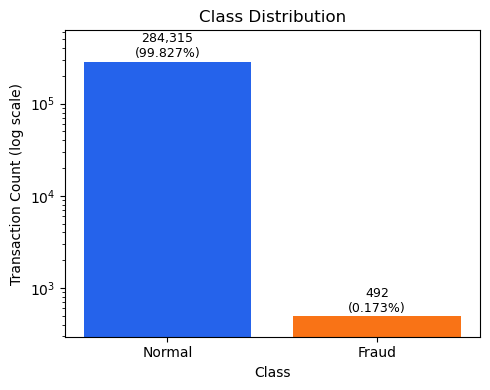

In [17]:
fig, ax = plt.subplots(figsize=(5, 4))
labels = ["Normal", "Fraud"]
bars = ax.bar(labels, class_counts.values, color=["#2563eb", "#f97316"])
ax.set_yscale("log")
ax.set_ylim(max(1, class_counts.min() * 0.6), class_counts.max() * 2.2)
ax.set_title("Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Transaction Count (log scale)")

for bar, count, percentage in zip(bars, class_counts.values, class_percentages.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        count * 1.04,
        f"{count:,.0f}\n({percentage:.3f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


## Missing Values and Duplicates

In [18]:
missing_values = df.isna().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

In [19]:
duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print(f"Duplicate rows: {duplicate_count}")
print(f"Duplicate percentage: {duplicate_percentage:.3f}%")

Duplicate rows: 1081
Duplicate percentage: 0.380%


## Amount and Time Overview

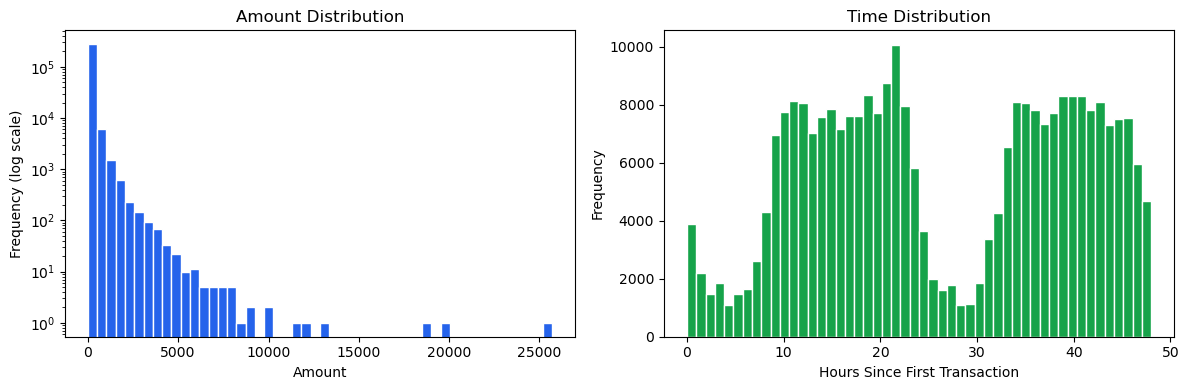

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Amount"], bins=50, color="#2563eb", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Amount Distribution")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Frequency (log scale)")

axes[1].hist(df["Time"] / 3600, bins=50, color="#16a34a", edgecolor="white")
axes[1].set_title("Time Distribution")
axes[1].set_xlabel("Hours Since First Transaction")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


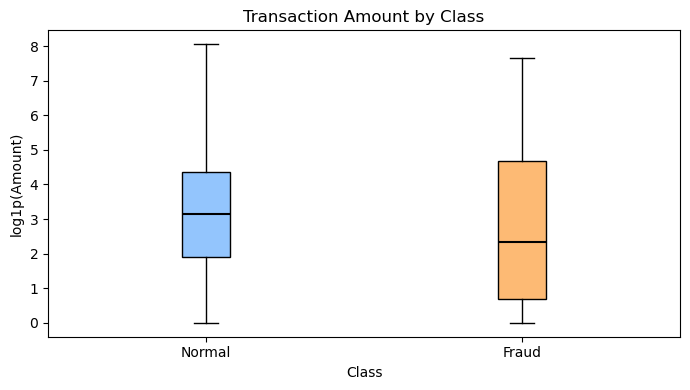

In [21]:
normal_amount = np.log1p(df.loc[df["Class"] == 0, "Amount"])
fraud_amount = np.log1p(df.loc[df["Class"] == 1, "Amount"])

fig, ax = plt.subplots(figsize=(7, 4))
box = ax.boxplot(
    [normal_amount, fraud_amount],
    tick_labels=["Normal", "Fraud"],
    showfliers=False,
    patch_artist=True,
    medianprops={"color": "black", "linewidth": 1.5},
)
for patch, color in zip(box["boxes"], ["#93c5fd", "#fdba74"]):
    patch.set_facecolor(color)

ax.set_title("Transaction Amount by Class")
ax.set_xlabel("Class")
ax.set_ylabel("log1p(Amount)")
plt.tight_layout()
plt.show()


## Saved Data-Understanding Figures

These figures are saved for the report to show the raw class imbalance and the main raw transaction distributions before preprocessing. The set is intentionally small so the report supports the modelling decisions without becoming excessive EDA.


D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\data_class_distribution_before_cleaning.png


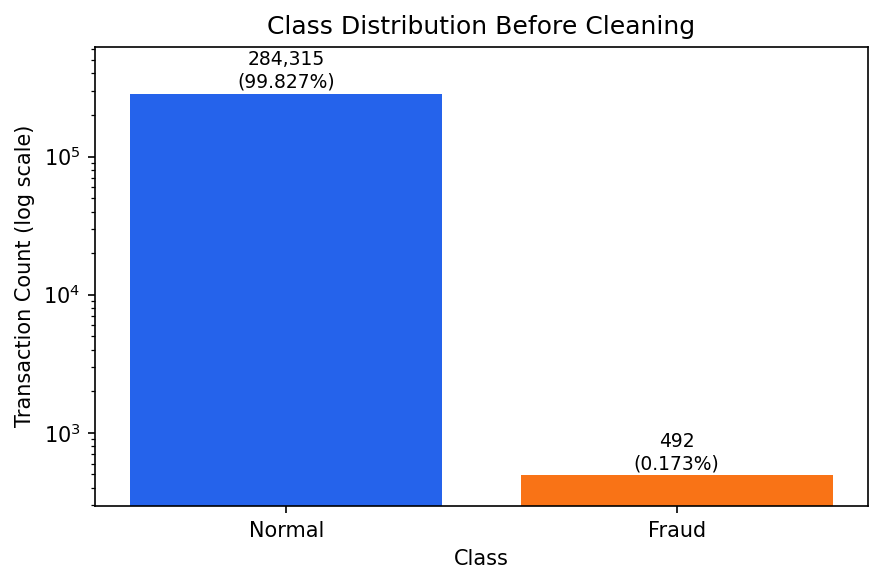

D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\data_amount_distribution_before_scaling.png


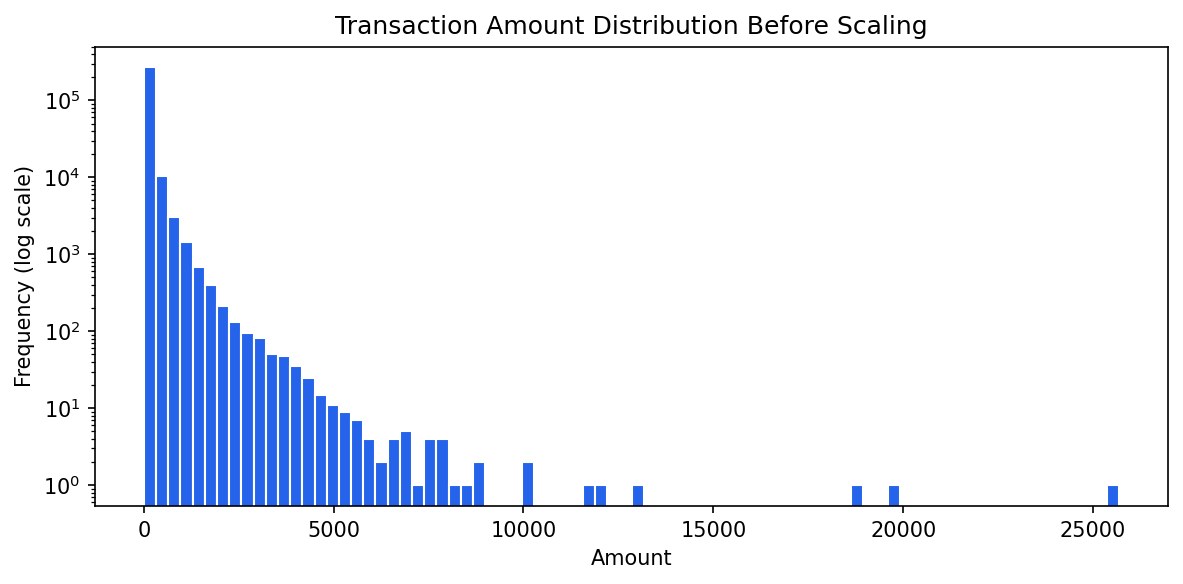

D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\data_amount_by_class_boxplot.png


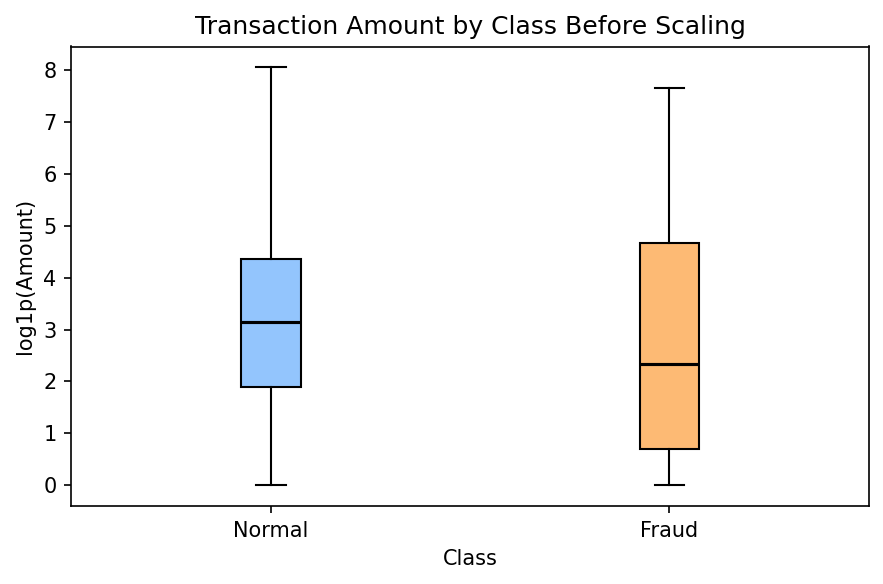

D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\data_time_distribution_by_class.png


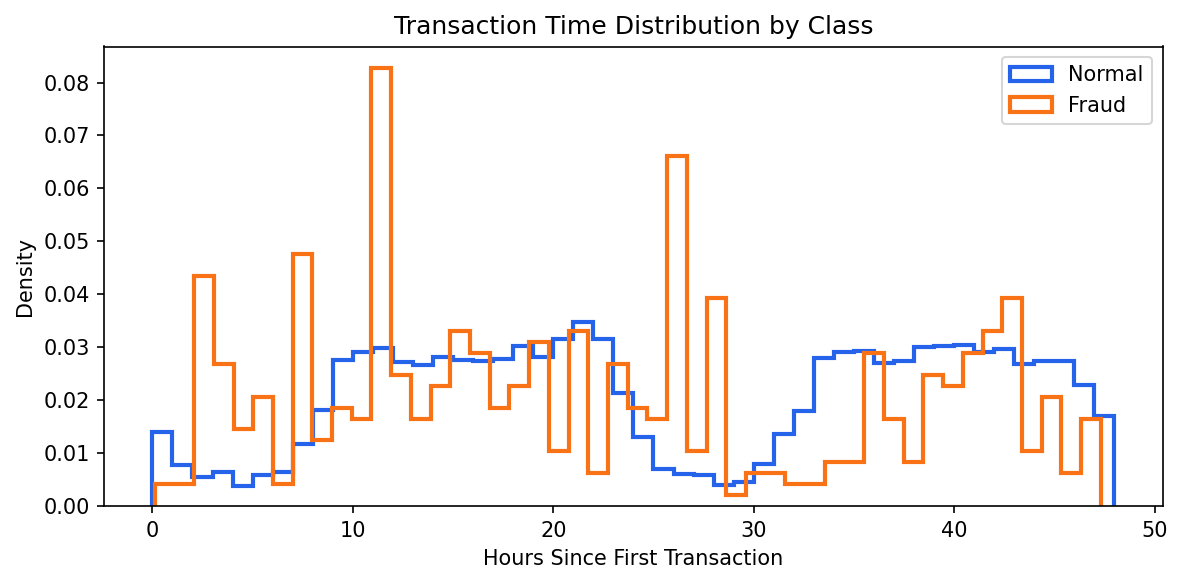

D:\Development_Studio\Python_Studio\ACML\Project\outputs\figures\data_feature_correlation_matrix_after_cleaning.png


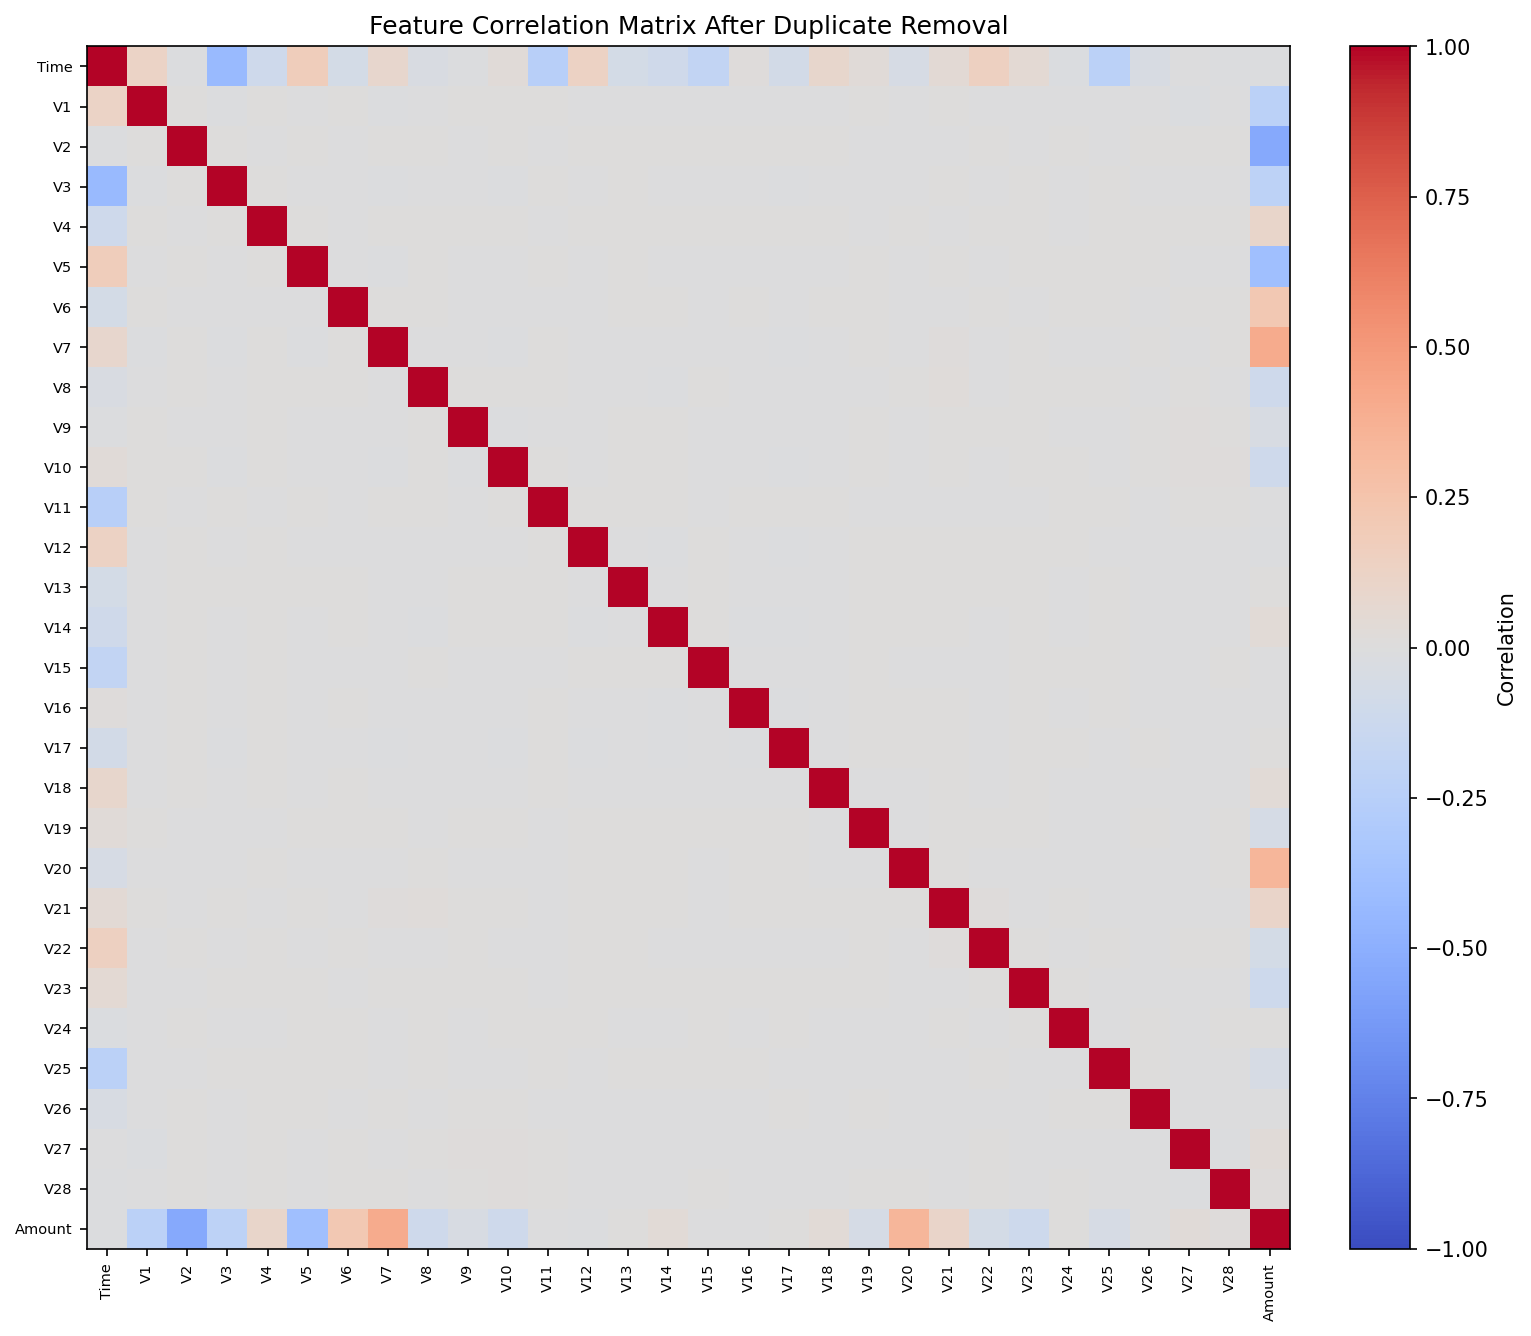

In [22]:
import sys
from IPython.display import Image, display
from pathlib import Path

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.preprocessing import (
    save_amount_by_class_boxplot,
    save_amount_distribution_plot,
    save_class_distribution_plot,
    save_feature_correlation_heatmap,
    save_time_distribution_by_class_plot,
)

figures_dir = project_root / "outputs" / "figures"
saved_data_figures = [
    save_class_distribution_plot(df, figures_dir),
    save_amount_distribution_plot(df, figures_dir),
    save_amount_by_class_boxplot(df, figures_dir),
    save_time_distribution_by_class_plot(df, figures_dir),
    save_feature_correlation_heatmap(df, figures_dir),
]

for figure_path in saved_data_figures:
    print(figure_path)
    display(Image(filename=str(figure_path)))


## Data Figure Interpretation

The class-distribution figure shows that fraud is a very rare class, around `0.17%` of transactions. This confirms that accuracy would be misleading and that precision, recall, F1, ROC-AUC, PR-AUC, and confusion matrices are more appropriate evaluation metrics.

The transaction amount histogram is strongly right-skewed, with many small transactions and a small number of very large transactions. This supports scaling `Amount` during preprocessing, while the amount-by-class boxplot shows that fraud and normal transactions have different amount patterns but still overlap too much for amount alone to classify fraud reliably.

The time-by-class plot suggests that fraud activity is not uniformly distributed across time, but the overlap with normal transactions means `Time` should be treated as one supporting feature rather than a direct rule. The correlation matrix shows mostly weak pairwise correlations among the PCA-transformed `V1` to `V28` features, which is expected for transformed components.


## Key Findings

- The dataset is large enough for machine learning experiments.
- The target is extremely imbalanced, so accuracy will not be used as the main performance metric.
- Fraud detection will be evaluated using precision, recall, F1, ROC-AUC, PR-AUC, and confusion matrices.
- `V1` to `V28` are already PCA-transformed numerical features.
- `Time` and `Amount` should be scaled during preprocessing.
- No missing-value imputation is expected if no missing values are found.
- Duplicate rows will be handled  before splitting the data.
- The next notebook preprocesses the data and creates train, validation, and test splits. 
